# 1. Proprocessing and feature engineering on Train Data

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp
import joblib
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from concurrent.futures import ThreadPoolExecutor

# Function to preprocess a chunk of the data
def preprocess_chunk(df_chunk):
    df_chunk['trans_date_trans_time'] = pd.to_datetime(df_chunk['trans_date_trans_time'])
    df_chunk['trans_hour'] = df_chunk['trans_date_trans_time'].dt.hour
    df_chunk['trans_month'] = df_chunk['trans_date_trans_time'].dt.month 
    df_chunk['trans_dayofweek'] = df_chunk['trans_date_trans_time'].dt.day_name()

    df_chunk['transaction_time'] = pd.to_datetime(df_chunk['unix_time'], unit='s')
    df_chunk = df_chunk.sort_values(by=['cc_num', 'transaction_time'])
    df_chunk['unix_time_prev_trans'] = df_chunk.groupby(by=['cc_num'])['unix_time'].shift(1)
    df_chunk = df_chunk.assign(unix_time_prev_trans=df_chunk['unix_time_prev_trans'].fillna(df_chunk['unix_time'] - 86400))
    df_chunk['timedelta_last_trans'] = (df_chunk['unix_time'] - df_chunk['unix_time_prev_trans']) // 60

    df_chunk['dob'] = pd.to_datetime(df_chunk['dob'])
    df_chunk['cust_age'] = (df_chunk['trans_date_trans_time'] - df_chunk['dob']).dt.days // 365

    return df_chunk

# Function to drop columns
def drop_columns(df):
    drop_cols = [
        'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
        'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
        'merch_lat', 'merch_long', 'dob'
    ]
    return df.drop(columns=drop_cols)

# Load the raw dataset in chunks and preprocess in parallel
df_chunks = pd.read_csv('../../data/raw/Fraudtrain.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_processed = pd.concat(executor.map(preprocess_chunk, df_chunks))

# Drop unnecessary columns
df_processed = drop_columns(df_processed)

# Split the data into X and y
X = df_processed.drop(columns=["is_fraud"])
y = df_processed["is_fraud"]

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# One-Hot Encoding for all categorical features
ohe = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Fit and transform the training data using sparse matrices
X_train_encoded_sparse = ohe.fit_transform(X_train[categorical_cols])

# Transform the validation data using sparse matrices
X_val_encoded_sparse = ohe.transform(X_val[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_train_sparse = sp.hstack((X_train.drop(columns=categorical_cols).values, X_train_encoded_sparse))
X_val_sparse = sp.hstack((X_val.drop(columns=categorical_cols).values, X_val_encoded_sparse))

# Save the OneHotEncoder for later use with the unseen data
joblib.dump(ohe, 'onehot_encoder.joblib')
# Display the shapes of the processed data
print("Training Data Shape:", X_train_sparse.shape)
print("Validation Data Shape:", X_val_sparse.shape)

['onehot_encoder.joblib']

# 2. Proprocessing and feature engineering on Unseen Test Data

In [ ]:
# Load the unseen dataset and preprocess in parallel as well
df_unseen_chunks = pd.read_csv('../../data/raw/Fraudtest.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_unseen_processed = pd.concat(executor.map(preprocess_chunk, df_unseen_chunks))

# Drop unnecessary columns
df_unseen_processed = drop_columns(df_unseen_processed)

# Separate features from target
X_unseen = df_unseen_processed.drop(columns=["is_fraud"])
y_unseen = df_unseen_processed["is_fraud"]

# Transform the unseen data using the saved OneHotEncoder
X_unseen_encoded_sparse = ohe.transform(X_unseen[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_unseen_sparse = sp.hstack((X_unseen.drop(columns=categorical_cols).values, X_unseen_encoded_sparse))

# Display the shape of the processed unseen data
print("\nUnseen Data Shape:", X_unseen_sparse.shape)

# 3. Model Building and Evalualtion

## 3.1 XGBoost

In [5]:
%%time
# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Number of features to select
n_features_to_select = 20

# Initialize RFE with the XGBoost model
rfe = RFE(estimator=xgb_model, n_features_to_select=n_features_to_select, step=1)

# Fit RFE on the sparse training data
rfe.fit(X_train_sparse, y_train)

# Transform the training, validation, and unseen datasets
X_train_rfe = rfe.transform(X_train_sparse)
X_val_rfe = rfe.transform(X_val_sparse)
X_unseen_rfe = rfe.transform(X_unseen_sparse)

# Save the selected feature indices
joblib.dump(rfe.get_support(indices=True), 'selected_indices.joblib')

# Display the shapes of the selected features
print("Selected Features for Training Data Shape:", X_train_rfe.shape)
print("Selected Features for Validation Data Shape:", X_val_rfe.shape)
print("Selected Features for Unseen Data Shape:", X_unseen_rfe.shape)

Selected Features for Training Data Shape: (907672, 20)
Selected Features for Validation Data Shape: (389003, 20)
Selected Features for Unseen Data Shape: (555719, 20)
CPU times: total: 13h 16min 47s
Wall time: 1h 8min 17s


In [6]:
# Load the OneHotEncoder to retrieve feature names
ohe = joblib.load('onehot_encoder.joblib')

# Get the original feature names before one-hot encoding
original_feature_names = X_train.drop(columns=categorical_cols).columns.tolist()

# Get the encoded feature names after one-hot encoding
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)

# Combine original and encoded feature names
all_feature_names = original_feature_names + list(encoded_feature_names)

# Load the selected feature indices from RFE
selected_indices = joblib.load('selected_indices.joblib')

# Get the names of the selected features
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# Display the selected feature names
print("Selected Feature Names:")
for feature_name in selected_feature_names:
    print(feature_name)


Selected Feature Names:
amt
trans_hour
timedelta_last_trans
cust_age
merchant_fraud_Hoppe, Harris and Bednar
category_food_dining
category_gas_transport
category_grocery_net
category_grocery_pos
category_health_fitness
category_home
category_kids_pets
category_misc_net
category_misc_pos
category_personal_care
category_shopping_net
category_shopping_pos
category_travel
gender_M
job_Museum/gallery conservator


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Train the model on the RFE-selected features of the training data
xgb_model.fit(X_train_rfe, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [8]:
# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe)[:, 1]

# Evaluate the model's performance on the validation data
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("Validation Data Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")


Validation Data Evaluation:
Accuracy: 0.9987
Precision: 0.9361
Recall: 0.8255
F1 Score: 0.8773
ROC AUC: 0.9989
PR AUC: 0.9340

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.94      0.83      0.88      2252

    accuracy                           1.00    389003
   macro avg       0.97      0.91      0.94    389003
weighted avg       1.00      1.00      1.00    389003


Confusion Matrix:
[[386624    127]
 [   393   1859]]
True Positives (TP): 1859
False Positives (FP): 127
True Negatives (TN): 386624
False Negatives (FN): 393


In [9]:
# Make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_rfe)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Evaluate the model's performance on the unseen data
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion matrix for unseen data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print("\nUnseen Data Evaluation:")
print(f"Accuracy: {accuracy_unseen:.4f}")
print(f"Precision: {precision_unseen:.4f}")
print(f"Recall: {recall_unseen:.4f}")
print(f"F1 Score: {f1_unseen:.4f}")
print(f"ROC AUC: {roc_auc_unseen:.4f}")
print(f"PR AUC: {pr_auc_unseen:.4f}")
print("\nClassification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("\nConfusion Matrix:")
print(conf_matrix_unseen)
print(f"True Positives (TP): {tp_unseen}")
print(f"False Positives (FP): {fp_unseen}")
print(f"True Negatives (TN): {tn_unseen}")
print(f"False Negatives (FN): {fn_unseen}")



Unseen Data Evaluation:
Accuracy: 0.9989
Precision: 0.8965
Recall: 0.7958
F1 Score: 0.8432
ROC AUC: 0.9980
PR AUC: 0.9068

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.80      0.84      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.90      0.92    555719
weighted avg       1.00      1.00      1.00    555719


Confusion Matrix:
[[553377    197]
 [   438   1707]]
True Positives (TP): 1707
False Positives (FP): 197
True Negatives (TN): 553377
False Negatives (FN): 438


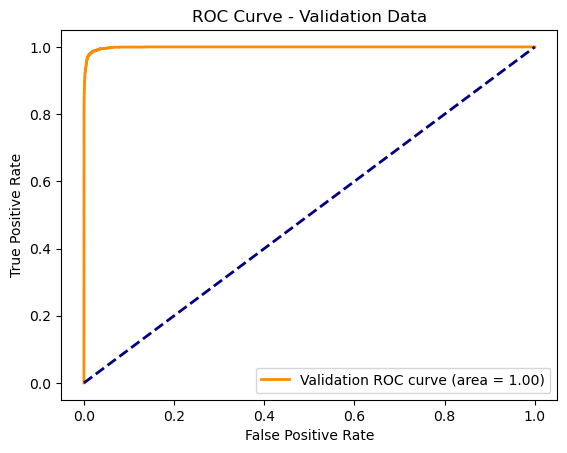

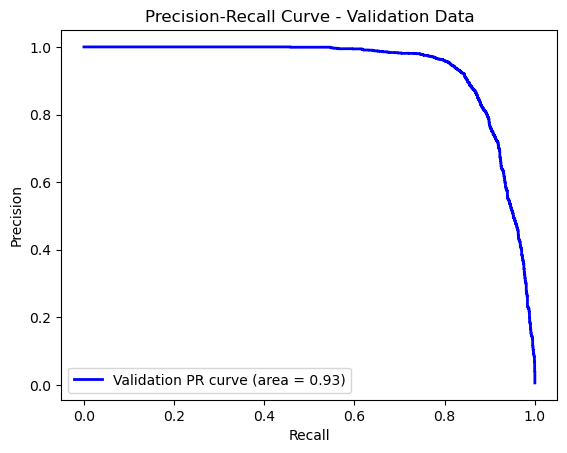

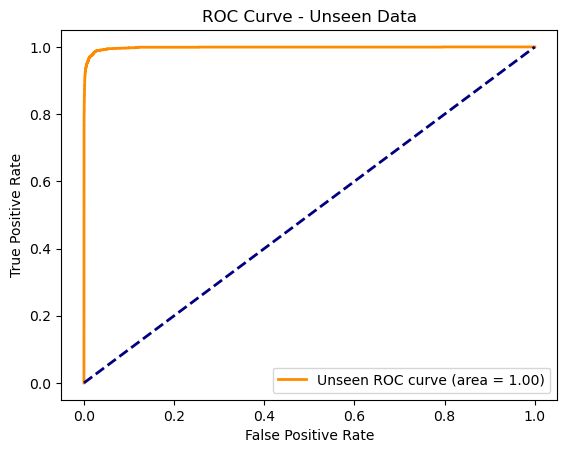

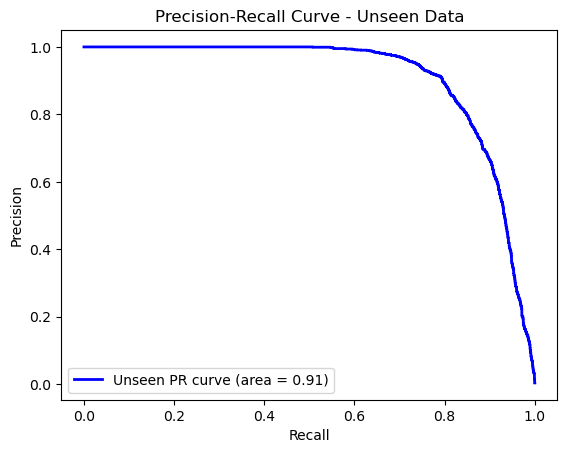

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve for Validation Data
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
plt.figure()
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Validation Data
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label='Validation PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()

# ROC Curve for Unseen Data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='Unseen ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Unseen Data
plt.figure()
plt.plot(recall_vals_unseen, precision_vals_unseen, color='blue', lw=2, label='Unseen PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


   Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0       0.02   0.351855  0.950583  0.513602  0.993050  0.997998  0.906773   
1       0.10   0.643804  0.905828  0.752663  0.997702  0.997998  0.906773   
2       0.20   0.748392  0.868065  0.803799  0.998364  0.997998  0.906773   
3       0.30   0.809758  0.843357  0.826216  0.998631  0.997998  0.906773   
4       0.40   0.860316  0.812587  0.835771  0.998767  0.997998  0.906773   
5       0.50   0.896534  0.795804  0.843171  0.998857  0.997998  0.906773   
6       0.60   0.916667  0.779487  0.842530  0.998875  0.997998  0.906773   
7       0.70   0.931034  0.755245  0.833977  0.998839  0.997998  0.906773   
8       0.80   0.954878  0.730070  0.827477  0.998825  0.997998  0.906773   

   True Positives (TP)  False Positives (FP)  True Negatives (TN)  \
0                 2039                  3756               549818   
1                 1943                  1075               552499   
2                 1862

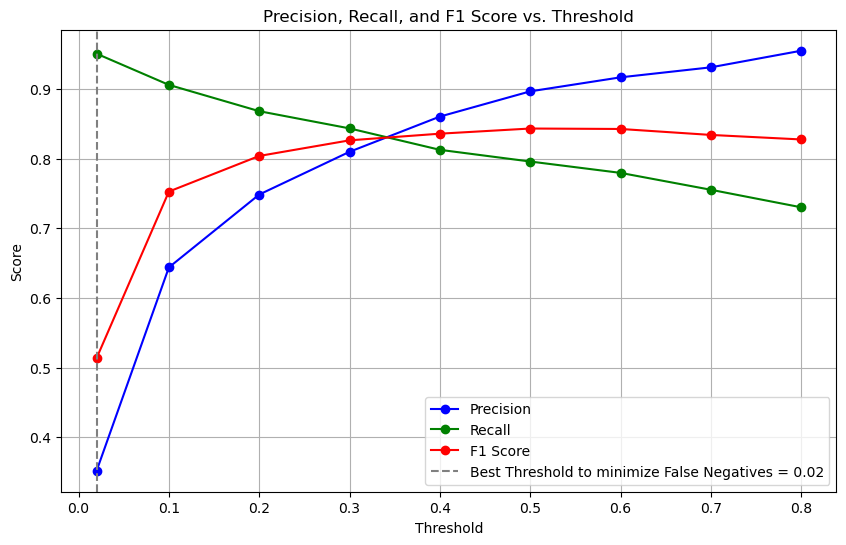

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.351855,0.950583,0.513602,0.993050,0.997998,0.906773,2039,3756,549818,106,203900,48160,155740
1,0.10,0.643804,0.905828,0.752663,0.997702,0.997998,0.906773,1943,1075,552499,202,194300,30950,163350
2,0.20,0.748392,0.868065,0.803799,0.998364,0.997998,0.906773,1862,626,552948,283,186200,34560,151640
3,0.30,0.809758,0.843357,0.826216,0.998631,0.997998,0.906773,1809,425,553149,336,180900,37850,143050
4,0.40,0.860316,0.812587,0.835771,0.998767,0.997998,0.906773,1743,283,553291,402,174300,43030,131270
5,0.50,0.896534,0.795804,0.843171,0.998857,0.997998,0.906773,1707,197,553377,438,170700,45770,124930
6,0.60,0.916667,0.779487,0.842530,0.998875,0.997998,0.906773,1672,152,553422,473,167200,48820,118380
7,0.70,0.931034,0.755245,0.833977,0.998839,0.997998,0.906773,1620,120,553454,525,162000,53700,108300
8,0.80,0.954878,0.730070,0.827477,0.998825,0.997998,0.906773,1566,74,553500,579,156600,58640,97960


In [36]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define the range of thresholds including 0.02
thresholds = np.append(np.arange(0.1, 0.9, 0.1), 0.02)
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


## Assumptions:

- **False Positive Cost (`fp_cost`):** \$10
- **False Negative Cost (`fn_cost`):** \$100
- **True Positive Savings (`tp_savings`):** \$100

## Recommendation:

### If Minimizing False Negatives (FN) is Critical:
**Threshold = 0.02** would still be the best choice as it catches most fraudulent transactions (Recall = 0.950583), but it has a lower precision and higher operational cost due to a large number of false positives. The net savings at this threshold are \$155,740.

### If a Balanced Approach is Preferred:
**Threshold = 0.10** offers the highest net savings (\$163,350). It balances a high recall (0.905828) with a reasonable precision (0.643804), leading to fewer false positives and false negatives. This threshold provides the best trade-off between saving money for stakeholders and maintaining a good detection rate.

### If Minimizing False Positives (FP) is Critical:
**Threshold = 0.50** or **Threshold = 0.60** could be preferred, offering high precision (0.896534 and 0.916667, respectively) and minimizing the number of legitimate transactions flagged as fraudulent. However, these thresholds result in lower net savings (124,930 dollars and 118,380 dollars, respectively) compared to the more balanced threshold at 0.10.

## Conclusion:
**Threshold = 0.10** is recommended for maximizing net savings for stakeholders, balancing the costs of false positives and false negatives. This threshold leads to the highest net savings (\$163,350), making it the most financially advantageous option.


## Recommendation:

### If Minimizing False Negatives (FN) is Critical:
**Threshold = 0.02** would be the best choice as it has the highest recall (0.950583), catching most fraudulent transactions, but with the trade-off of a lower precision (0.351855) and a higher number of false positives (3756).

### If a Balanced Approach is Preferred:
**Threshold = 0.30** is likely the best overall option. It provides a good balance between recall (0.843357) and precision (0.809758), and it has a strong F1 score (0.826216). This threshold reduces the number of false positives (425) while still maintaining a high recall.

### If Minimizing False Positives (FP) is Critical:
**Threshold = 0.50** or **Threshold = 0.60** could be preferred. These thresholds have high precision (0.896534 and 0.916667, respectively), meaning they minimize the number of legitimate transactions flagged as fraudulent, but at the cost of missing more fraudulent transactions (recall is 0.795804 and 0.779487, respectively).

## Conclusion:
**Threshold = 0.30** might be the best overall choice for a balanced fraud detection model, offering a good trade-off between recall and precision, with a reasonable number of false positives (425) and false negatives (336). However, if the business prioritizes catching every possible fraudulent transaction, even at the cost of more false positives, **Threshold = 0.02** would be preferred.


In [12]:
import joblib

# Save the processed training dataset
joblib.dump((X_train_rfe, y_train), 'X_train_rfe_y_train.joblib')

# Save the processed validation dataset
joblib.dump((X_val_rfe, y_val), 'X_val_rfe_y_val.joblib')

# Save the processed unseen dataset
joblib.dump((X_unseen_rfe, y_unseen), 'X_unseen_rfe_y_unseen.joblib')

# Save the trained XGBoost model
joblib.dump(xgb_model, 'final_model_20_features.joblib')


['final_model_20_features.joblib']

In [13]:
# Load the training dataset
X_train_rfe, y_train = joblib.load('X_train_rfe_y_train.joblib')

# Load the validation dataset
X_val_rfe, y_val = joblib.load('X_val_rfe_y_val.joblib')

# Load the unseen dataset
X_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen.joblib')

# Load the trained XGBoost model
xgb_model = joblib.load('final_model_20_features.joblib')


In [21]:
X_train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'city_pop', 'job', 'trans_hour', 'trans_month', 'trans_dayofweek',
       'timedelta_last_trans', 'cust_age'],
      dtype='object')

In [30]:
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_dayofweek']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)


In [31]:
original_numeric_features = ['cc_num', 'amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans', 'cust_age']
final_feature_names = list(original_numeric_features) + list(ohe_feature_names)


In [33]:
selected_feature_indices = rfe.get_support(indices=True)
selected_feature_names = [final_feature_names[i] for i in selected_feature_indices]
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe)


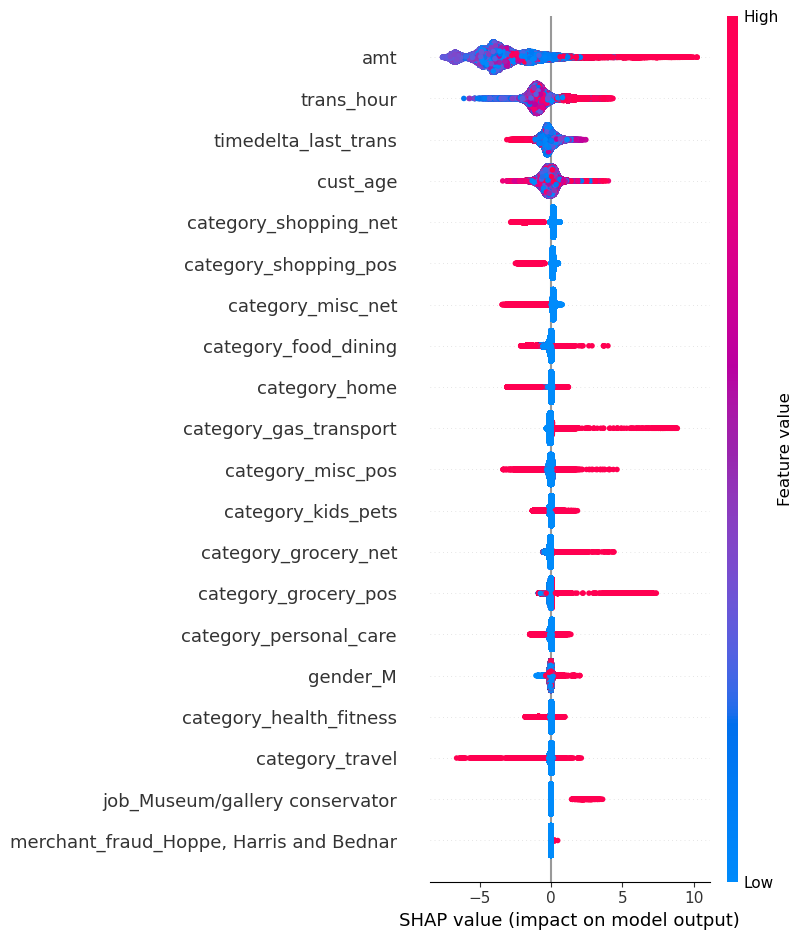

In [34]:
import shap

# Assuming `shap_values` and `explainer` are already computed
shap.summary_plot(shap_values, features=X_val_rfe.toarray(), feature_names=selected_feature_names)


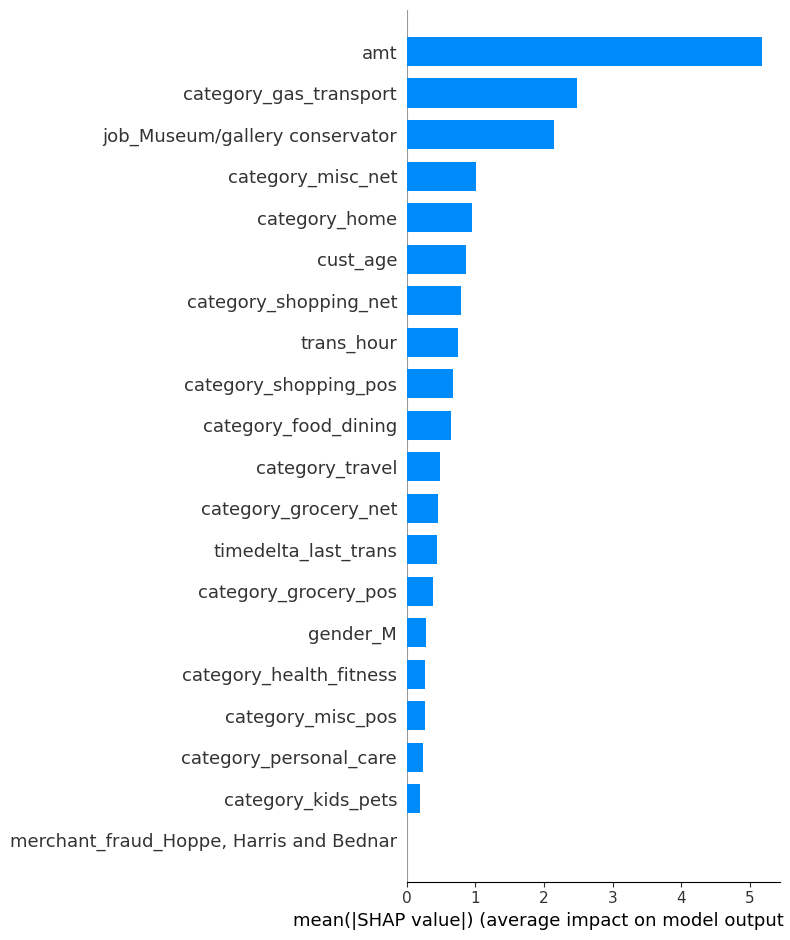

In [37]:
import shap
import numpy as np
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Assuming `X_val_rfe` is a sparse matrix, convert it to dense
X_val_rfe_dense = X_val_rfe.toarray()

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe_dense)

# Assuming `selected_feature_names` is a list of the RFE-selected feature names
# Summary plot of SHAP values
shap.summary_plot(shap_values, X_val_rfe_dense, feature_names=selected_feature_names, plot_type="bar")

### Cross validation and hyper parameter tunning

In [38]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_rfe, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9991 ± 0.0000, Test: 0.9987 ± 0.0001
Precision - Train: 0.9718 ± 0.0013, Test: 0.9396 ± 0.0070
Recall - Train: 0.8770 ± 0.0024, Test: 0.8291 ± 0.0151
F1 - Train: 0.9220 ± 0.0012, Test: 0.8808 ± 0.0100
Roc_auc - Train: 0.9997 ± 0.0000, Test: 0.9986 ± 0.0004
CPU times: total: 6min 11s
Wall time: 28.3 s


In [41]:
%%time
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import joblib
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',  # Optimize for roc_auc
    n_jobs=-1,  # Use all available processors
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_rfe, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

Best Parameters: OrderedDict([('learning_rate', 0.19737932365202507), ('max_depth', 7), ('n_estimators', 62), ('scale_pos_weight', 108)])
Best Cross-Validation ROC AUC Score: 0.9984051477191018
CPU times: total: 29.5 s
Wall time: 10min 47s


Unseen Data Accuracy (Fixed Threshold): 0.9922964663795911
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.33      0.95      0.49      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.97      0.74    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 549390, FP: 4184, FN: 97, TP: 2048
[[549390   4184]
 [    97   2048]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.99786763020748
Unseen Data PR AUC Score (Fixed Threshold): 0.8975095544745334


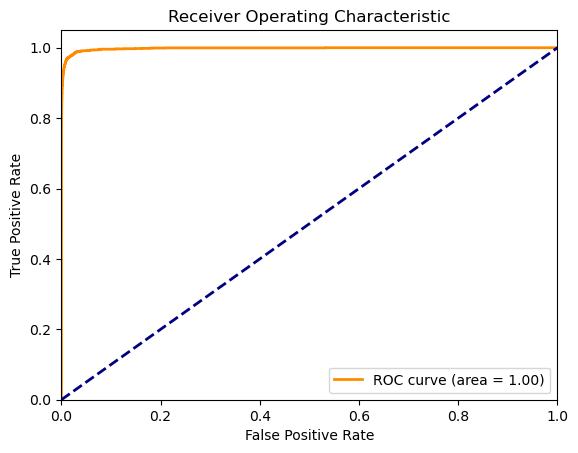

In [42]:
# Use the best model for predictions
best_xgb_model = bayes_search.best_estimator_

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Apply the fixed threshold of 0.5 to the predictions
fixed_threshold = 0.5
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [43]:
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = bayes_search.best_estimator_
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_rfe, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_rfe)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_rfe)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')


Validation Accuracy: 0.9643
Validation Precision: 0.1379
Validation Recall: 0.9840
Validation F1 Score: 0.2420
Validation ROC-AUC: 0.9969
Validation PR AUC: 0.8768
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    386751
           1       0.14      0.98      0.24      2252

    accuracy                           0.96    389003
   macro avg       0.57      0.97      0.61    389003
weighted avg       0.99      0.96      0.98    389003

Validation Confusion Matrix:
[[372903  13848]
 [    36   2216]]
True Positives (TP): 2216
False Positives (FP): 13848
True Negatives (TN): 372903
False Negatives (FN): 36


Unseen Data Accuracy: 0.9643
Unseen Data Precision: 0.0962
Unseen Data Recall: 0.9818
Unseen Data F1 Score: 0.1753
Unseen Data ROC-AUC: 0.9960
Unseen Data PR AUC: 0.8332
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.10      0.98      0.18      2145

    accuracy                           0.96    555719
   macro avg       0.55      0.97      0.58    555719
weighted avg       1.00      0.96      0.98    555719

Unseen Data Confusion Matrix:
[[533792  19782]
 [    39   2106]]
True Positives (TP): 2106
False Positives (FP): 19782
True Negatives (TN): 533792
False Negatives (FN): 39


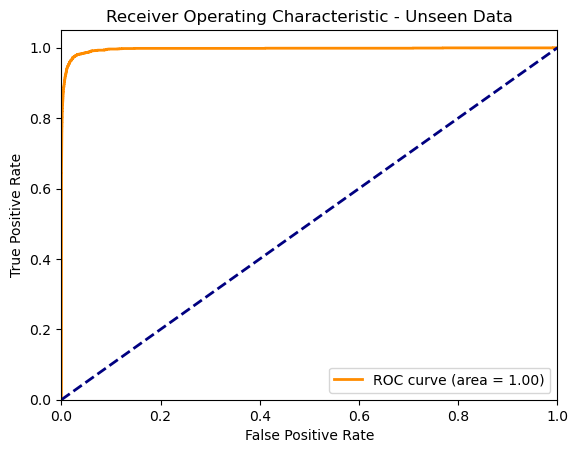

In [44]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_rfe)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

Unseen Data Accuracy: 0.9643
Unseen Data Precision: 0.0962
Unseen Data Recall: 0.9818
Unseen Data F1 Score: 0.1753
Unseen Data ROC-AUC: 0.9960
Unseen Data PR AUC: 0.8332
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.10      0.98      0.18      2145

    accuracy                           0.96    555719
   macro avg       0.55      0.97      0.58    555719
weighted avg       1.00      0.96      0.98    555719

Unseen Data Confusion Matrix:
[[533792  19782]
 [    39   2106]]
True Positives (TP): 2106
False Positives (FP): 19782
True Negatives (TN): 533792
False Negatives (FN): 39


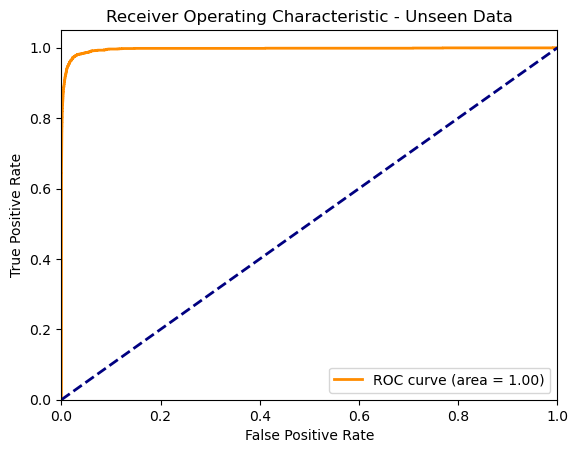

    Threshold  Precision    Recall  F1 Score  Accuracy  ROC AUC    PR AUC  \
0        0.02   0.019996  0.998135  0.039207  0.811174  0.99597  0.833245   
1        0.10   0.038793  0.995804  0.074677  0.904747  0.99597  0.833245   
2        0.20   0.053522  0.991608  0.101561  0.932282  0.99597  0.833245   
3        0.30   0.067466  0.986946  0.126298  0.947294  0.99597  0.833245   
4        0.40   0.081827  0.983683  0.151087  0.957333  0.99597  0.833245   
5        0.50   0.096217  0.981818  0.175259  0.964333  0.99597  0.833245   
6        0.60   0.112759  0.978555  0.202216  0.970197  0.99597  0.833245   
7        0.70   0.133389  0.972960  0.234613  0.975497  0.99597  0.833245   
8        0.80   0.162158  0.964103  0.277621  0.980634  0.99597  0.833245   
9        0.90   0.213933  0.949184  0.349168  0.986342  0.99597  0.833245   
10       0.95   0.269542  0.932401  0.418191  0.989986  0.99597  0.833245   
11       0.98   0.347935  0.907226  0.502972  0.993079  0.99597  0.833245   

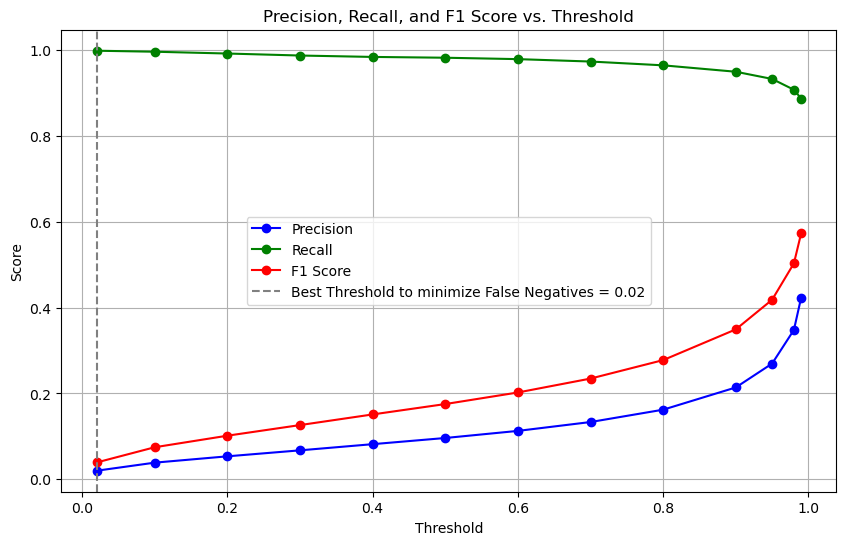

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.019996,0.998135,0.039207,0.811174,0.99597,0.833245,2141,104930,448644,4,214100,1049700,-835600
1,0.10,0.038793,0.995804,0.074677,0.904747,0.99597,0.833245,2136,52925,500649,9,213600,530150,-316550
2,0.20,0.053522,0.991608,0.101561,0.932282,0.99597,0.833245,2127,37614,515960,18,212700,377940,-165240
3,0.30,0.067466,0.986946,0.126298,0.947294,0.99597,0.833245,2117,29262,524312,28,211700,295420,-83720
4,0.40,0.081827,0.983683,0.151087,0.957333,0.99597,0.833245,2110,23676,529898,35,211000,240260,-29260
5,0.50,0.096217,0.981818,0.175259,0.964333,0.99597,0.833245,2106,19782,533792,39,210600,201720,8880
6,0.60,0.112759,0.978555,0.202216,0.970197,0.99597,0.833245,2099,16516,537058,46,209900,169760,40140
7,0.70,0.133389,0.972960,0.234613,0.975497,0.99597,0.833245,2087,13559,540015,58,208700,141390,67310
8,0.80,0.162158,0.964103,0.277621,0.980634,0.99597,0.833245,2068,10685,542889,77,206800,114550,92250
9,0.90,0.213933,0.949184,0.349168,0.986342,0.99597,0.833245,2036,7481,546093,109,203600,85710,117890


In [51]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_rfe)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


## 3.2 Stacking classifier

[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 650
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
[LightGBM] [Info] Number of positive: 4203, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 650
[LightGBM] [Info] Number of data points in the train set: 726137, number of used features: 20
[LightGBM] [Info] 

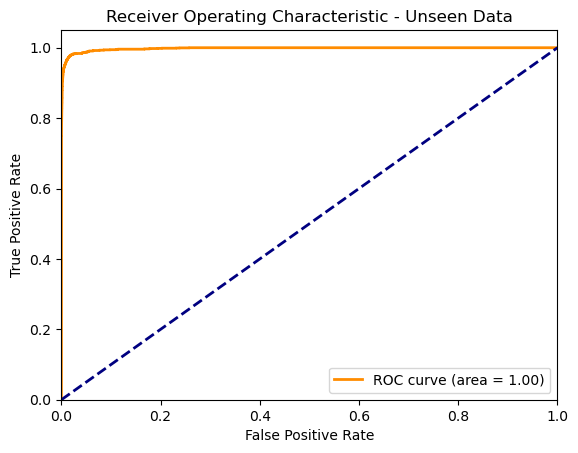

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_clas

    Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0        0.02   0.351449  0.949650  0.513034  0.993041  0.997579  0.893778   
1        0.10   0.443005  0.940326  0.602269  0.995206  0.997579  0.893778   
2        0.20   0.498255  0.931935  0.649342  0.996115  0.997579  0.893778   
3        0.30   0.547070  0.918415  0.685694  0.996750  0.997579  0.893778   
4        0.40   0.599938  0.908159  0.722552  0.997308  0.997579  0.893778   
5        0.50   0.661223  0.887179  0.757715  0.997810  0.997579  0.893778   
6        0.60   0.722046  0.848951  0.780373  0.998156  0.997579  0.893778   
7        0.70   0.841356  0.798601  0.819421  0.998641  0.997579  0.893778   
8        0.80   0.000000  0.000000  0.000000  0.996140  0.997579  0.893778   
9        0.90   0.000000  0.000000  0.000000  0.996140  0.997579  0.893778   
10       0.95   0.000000  0.000000  0.000000  0.996140  0.997579  0.893778   
11       0.98   0.000000  0.000000  0.000000  0.996140  0.997579

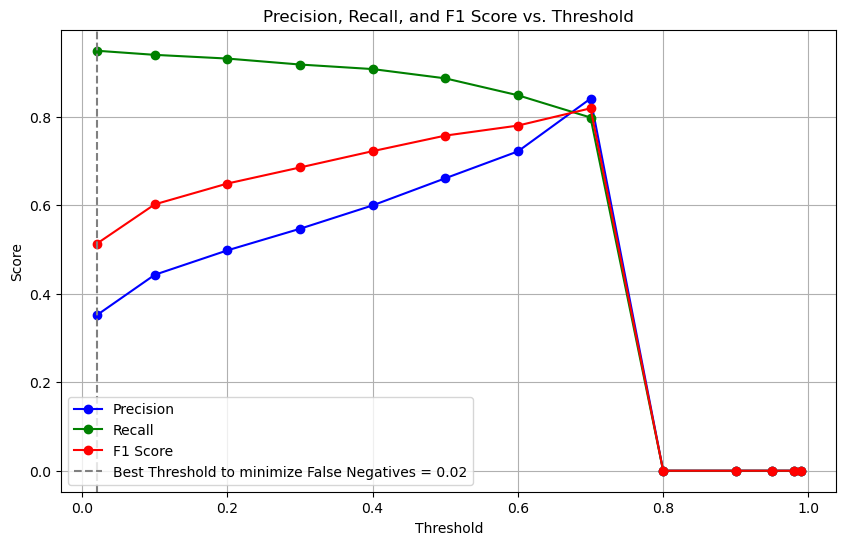

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.351449,0.949650,0.513034,0.993041,0.997579,0.893778,2037,3759,549815,108,203700,48390,155310
1,0.10,0.443005,0.940326,0.602269,0.995206,0.997579,0.893778,2017,2536,551038,128,201700,38160,163540
2,0.20,0.498255,0.931935,0.649342,0.996115,0.997579,0.893778,1999,2013,551561,146,199900,34730,165170
3,0.30,0.547070,0.918415,0.685694,0.996750,0.997579,0.893778,1970,1631,551943,175,197000,33810,163190
4,0.40,0.599938,0.908159,0.722552,0.997308,0.997579,0.893778,1948,1299,552275,197,194800,32690,162110
5,0.50,0.661223,0.887179,0.757715,0.997810,0.997579,0.893778,1903,975,552599,242,190300,33950,156350
6,0.60,0.722046,0.848951,0.780373,0.998156,0.997579,0.893778,1821,701,552873,324,182100,39410,142690
7,0.70,0.841356,0.798601,0.819421,0.998641,0.997579,0.893778,1713,323,553251,432,171300,46430,124870
8,0.80,0.000000,0.000000,0.000000,0.996140,0.997579,0.893778,0,0,553574,2145,0,214500,-214500
9,0.90,0.000000,0.000000,0.000000,0.996140,0.997579,0.893778,0,0,553574,2145,0,214500,-214500


In [56]:
# Import necessary libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate scale_pos_weight using the given formula
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define base models
base_models = [
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lgb', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
]

# Define stacking classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Train stacking model
stack_model.fit(X_train_rfe, y_train)

# Model Evaluation on Unseen Data
y_unseen_pred = stack_model.predict(X_unseen_rfe)
y_unseen_pred_proba = stack_model.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion Matrix for Unseen Data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred_threshold)
    recall = recall_score(y_unseen, y_pred_threshold)
    f1 = f1_score(y_unseen, y_pred_threshold)
    accuracy = accuracy_score(y_unseen, y_pred_threshold)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred_threshold).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.2, color='gray', linestyle='--', label='Best Threshold to Maximize the net saved $ False Negatives = 0.2')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


## 3.3 Stacking classifier with ADASYN

[LightGBM] [Info] Number of positive: 902453, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4890
[LightGBM] [Info] Number of data points in the train set: 1804871, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500010 -> initscore=0.000039
[LightGBM] [Info] Start training from score 0.000039
[LightGBM] [Info] Number of positive: 721962, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4865
[LightGBM] [Info] Number of data points in the train set: 1443896, number of used features: 20
[LightGBM] [

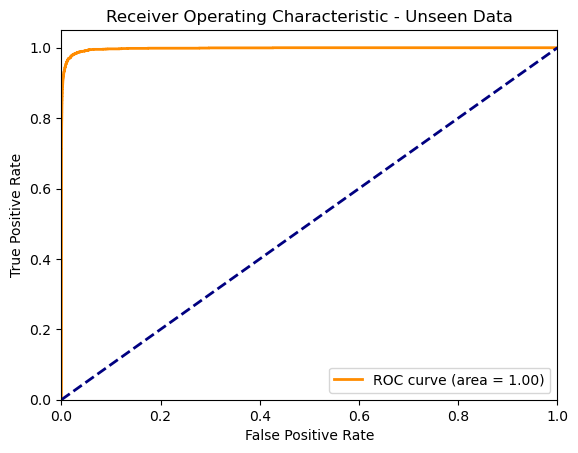

    Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0        0.02   0.287240  0.952914  0.441421  0.990691  0.997691  0.881835   
1        0.10   0.395376  0.932867  0.555371  0.994234  0.997691  0.881835   
2        0.20   0.445444  0.923077  0.600910  0.995267  0.997691  0.881835   
3        0.30   0.480586  0.917483  0.630769  0.995854  0.997691  0.881835   
4        0.40   0.506587  0.914219  0.651928  0.996232  0.997691  0.881835   
5        0.50   0.530596  0.909557  0.670216  0.996545  0.997691  0.881835   
6        0.60   0.554314  0.901632  0.686546  0.996822  0.997691  0.881835   
7        0.70   0.577270  0.895105  0.701883  0.997065  0.997691  0.881835   
8        0.80   0.607768  0.889977  0.722285  0.997358  0.997691  0.881835   
9        0.90   0.647668  0.874126  0.744048  0.997679  0.997691  0.881835   
10       0.95   0.693178  0.857343  0.766569  0.997985  0.997691  0.881835   
11       0.98   0.745756  0.839627  0.789912  0.998276  0.997691

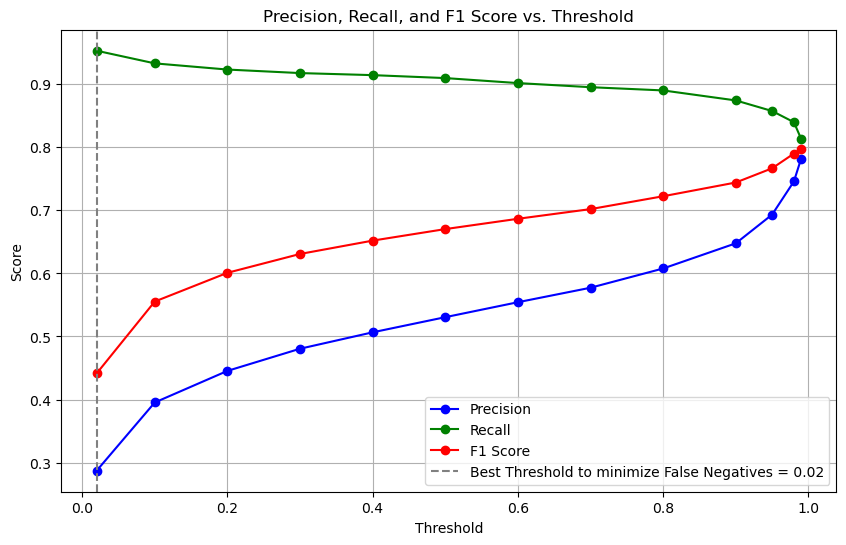

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.287240,0.952914,0.441421,0.990691,0.997691,0.881835,2044,5072,548502,101,204400,60820,143580
1,0.10,0.395376,0.932867,0.555371,0.994234,0.997691,0.881835,2001,3060,550514,144,200100,45000,155100
2,0.20,0.445444,0.923077,0.600910,0.995267,0.997691,0.881835,1980,2465,551109,165,198000,41150,156850
3,0.30,0.480586,0.917483,0.630769,0.995854,0.997691,0.881835,1968,2127,551447,177,196800,38970,157830
4,0.40,0.506587,0.914219,0.651928,0.996232,0.997691,0.881835,1961,1910,551664,184,196100,37500,158600
5,0.50,0.530596,0.909557,0.670216,0.996545,0.997691,0.881835,1951,1726,551848,194,195100,36660,158440
6,0.60,0.554314,0.901632,0.686546,0.996822,0.997691,0.881835,1934,1555,552019,211,193400,36650,156750
7,0.70,0.577270,0.895105,0.701883,0.997065,0.997691,0.881835,1920,1406,552168,225,192000,36560,155440
8,0.80,0.607768,0.889977,0.722285,0.997358,0.997691,0.881835,1909,1232,552342,236,190900,35920,154980
9,0.90,0.647668,0.874126,0.744048,0.997679,0.997691,0.881835,1875,1020,552554,270,187500,37200,150300


In [57]:
# Import necessary libraries
from imblearn.over_sampling import ADASYN
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Apply ADASYN to the training data
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_rfe, y_train)

# Recalculate scale_pos_weight after ADASYN
scale_pos_weight_adasyn = (y_train_adasyn == 0).sum() / (y_train_adasyn == 1).sum()

# Define base models with the recalculated scale_pos_weight
base_models = [
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_adasyn, random_state=42)),
    ('lgb', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight_adasyn, random_state=42))
]

# Define stacking classifier
stack_model_adasyn = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Train stacking model on ADASYN data
stack_model_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Model Evaluation on Unseen Data
y_unseen_pred = stack_model_adasyn.predict(X_unseen_rfe)
y_unseen_pred_proba = stack_model_adasyn.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion Matrix for Unseen Data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred_threshold)
    recall = recall_score(y_unseen, y_pred_threshold)
    f1 = f1_score(y_unseen, y_pred_threshold)
    accuracy = accuracy_score(y_unseen, y_pred_threshold)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred_threshold).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.4, color='gray', linestyle='--', label='Best Threshold to Maximize the net saved $ False Negatives = 0.4')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


In [ ]:
import joblib

# Define the paths where you want to save the models and data
xgb_model_path = "best_xgb_model_ADASYN.joblib"
stack_model_path = "stack_model.joblib"
stack_model_adasyn_path = "stack_model_ADASYN.joblib"
resampled_data_path = "resampled_data_ADASYN.joblib"

# Save the best XGBoost model trained on ADASYN data
joblib.dump(best_xgb_model_ADASYN, xgb_model_path)

# Save the stacking model (without ADASYN)
joblib.dump(stack_model, stack_model_path)

# Save the stacking model trained on ADASYN data
joblib.dump(stack_model_adasyn, stack_model_adasyn_path)

# Save the resampled data (X_train_adasyn and y_train_adasyn)
resampled_data = {
    'X_train_adasyn': X_train_adasyn,
    'y_train_adasyn': y_train_adasyn
}
joblib.dump(resampled_data, resampled_data_path)

print(f"Models and data have been saved to the following paths:\n"
      f"XGBoost model: {xgb_model_path}\n"
      f"Stacking model: {stack_model_path}\n"
      f"Stacking model with ADASYN: {stack_model_adasyn_path}\n"
      f"Resampled data: {resampled_data_path}")


In [ ]:
best_xgb_model_ADASYN = joblib.load("best_xgb_model_ADASYN.joblib")
stack_model = joblib.load("stack_model.joblib")
stack_model_adasyn = joblib.load("stack_model_ADASYN.joblib")
resampled_data = joblib.load("resampled_data_ADASYN.joblib")

X_train_adasyn = resampled_data['X_train_adasyn']
y_train_adasyn = resampled_data['y_train_adasyn']

## 3.4 Different models to evaluate on unseen data after ADASYN resampled

In [ ]:
%%time

# Import necessary libraries
from imblearn.over_sampling import ADASYN
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Apply ADASYN to the training data
adasyn = ADASYN(random_state=42, n_jobs=-1)  # Run ADASYN in parallel
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_rfe, y_train)

# List of classifiers to evaluate (optimized for speed)
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Artificial Neural Network (ANN)': MLPClassifier(max_iter=1000, random_state=42)  # Reduced max_iter for ANN
}

# Initialize a list to store metrics for each classifier
all_metrics = []

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

# Iterate over classifiers
for name, clf in classifiers.items():
    # Train the classifier on the ADASYN data
    clf.fit(X_train_adasyn, y_train_adasyn)

    # Make predictions on the unseen data
    y_unseen_pred = clf.predict(X_unseen_rfe)
    y_unseen_pred_proba = clf.predict_proba(X_unseen_rfe)[:, 1]

    # Evaluate standard metrics
    accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
    precision_unseen = precision_score(y_unseen, y_unseen_pred)
    recall_unseen = recall_score(y_unseen, y_unseen_pred)
    f1_unseen = f1_score(y_unseen, y_unseen_pred)
    roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
    precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
    pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

    # Confusion Matrix for Unseen Data
    conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
    tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

    # Store the standard metrics
    all_metrics.append({
        'Classifier': name,
        'Threshold': 'Default',
        'Precision': precision_unseen,
        'Recall': recall_unseen,
        'F1 Score': f1_unseen,
        'Accuracy': accuracy_unseen,
        'ROC AUC': roc_auc_unseen,
        'PR AUC': pr_auc_unseen,
        'True Positives (TP)': tp_unseen,
        'False Positives (FP)': fp_unseen,
        'True Negatives (TN)': tn_unseen,
        'False Negatives (FN)': fn_unseen,
        'Total Savings ($)': tp_unseen * tp_savings,
        'Cost of Operation ($)': (fp_unseen * fp_cost) + (fn_unseen * fn_cost),
        'Net Savings ($)': (tp_unseen * tp_savings) - ((fp_unseen * fp_cost) + (fn_unseen * fn_cost))
    })

    # Threshold-based evaluation
    for threshold in thresholds:
        # Apply the threshold to the predictions
        y_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
        
        # Calculate the metrics
        precision = precision_score(y_unseen, y_pred_threshold)
        recall = recall_score(y_unseen, y_pred_threshold)
        f1 = f1_score(y_unseen, y_pred_threshold)
        accuracy = accuracy_score(y_unseen, y_pred_threshold)
        roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
        pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
        
        # Confusion matrix values
        tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred_threshold).ravel()
        
        # Calculate costs and savings
        total_savings = tp * tp_savings
        cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
        net_savings = total_savings - cost_of_operation
        
        # Store the metrics for this threshold
        all_metrics.append({
            'Classifier': name,
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'Accuracy': accuracy,
            'ROC AUC': roc_auc,
            'PR AUC': pr_auc,
            'True Positives (TP)': tp,
            'False Positives (FP)': fp,
            'True Negatives (TN)': tn,
            'False Negatives (FN)': fn,
            'Total Savings ($)': total_savings,
            'Cost of Operation ($)': cost_of_operation,
            'Net Savings ($)': net_savings
        })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(all_metrics)

# Display the metrics DataFrame
print(metrics_df)

# Plot the metrics vs. Threshold for each classifier
plt.figure(figsize=(12, 8))
for name in classifiers.keys():
    subset = metrics_df[metrics_df['Classifier'] == name]
    plt.plot(subset['Threshold'], subset['F1 Score'], marker='o', label=f'{name} - F1 Score')

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Threshold for Different Classifiers')
plt.legend()
plt.grid()
plt.show()

# Display the final DataFrame
metrics_df


C:\Users\Black\anaconda3\Lib\site-packages\imblearn\over_sampling\_adasyn.py:156: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
